# AQI Data Warehouse — Exploratory Analysis

Individual analysis notebook, based on the `fact_air_quality` / `dim_city` / `dim_time`
star schema loaded in our Neon Postgres warehouse.

**Goals of this notebook:**
1. Connect to the warehouse and load the data into a single analysis-ready DataFrame
2. Overview of coverage (rows per city, date range, missing values)
3. AQI comparison across the 5 cities
4. Time trends (daily/weekly evolution, pollution peaks)
5. Correlations between pollutants
6. Weekday vs weekend and hour-of-day patterns

1. Setup & Connection

We load environment variables and open a single SQLAlchemy engine — reused by every query below instead of reconnecting each time.

In [ ]:
#setup
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

DATABASE_URL = os.getenv("DATABASE_URL")

#print(f"✅ DATABASE_URL found: {DATABASE_URL[:30]}..." if DATABASE_URL else "❌ DATABASE_URL not found! Create a .env file with DATABASE_URL=...")
if not DATABASE_URL:
    raise ValueError("❌ Nooooooooooooo DATABASE_URL not found! Create a .env file with DATABASE_URL=...")

engine = create_engine(DATABASE_URL)
print("Yessssss the data_warehouse is connected successfully!" if engine else "Connection object not created.")

Yessssss the data_warehouse is connected successfully!


2. Loading the data

We join the fact table with both dimensions into one flat DataFrame — the most convenient shape for exploratory analysis in pandas.

In [11]:
query = """
SELECT
    c.city_name,
    c.country,
    c.latitude,
    c.longitude,
    t.timestamp_utc,
    t.date,
    t.hour,
    t.day_of_week,
    t.day_name,
    t.is_weekend,
    f.aqi,
    f.co, f.no, f.no2, f.o3, f.so2, f.pm2_5, f.pm10, f.nh3
FROM fact_air_quality f
JOIN dim_city c ON c.city_key = f.city_key
JOIN dim_time t ON t.time_key = f.time_key
ORDER BY c.city_name, t.timestamp_utc
"""

df = pd.read_sql(query, engine)
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)
print(f"{len(df):,} rows loaded, {df['city_name'].nunique()} cities")
df

10,368 rows loaded, 5 cities


,city_name,country,latitude,longitude,timestamp_utc,date,hour,day_of_week,day_name,is_weekend,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3
0,Antananarivo,MG,-18.8792,47.5079,2026-04-26 12:00:00+00:00,2026-04-26,12,6,Dimanche,True,1,62.86,0.03,0.10,43.89,0.12,0.87,1.58,0.41
1,Antananarivo,MG,-18.8792,47.5079,2026-04-26 13:00:00+00:00,2026-04-26,13,6,Dimanche,True,1,67.81,0.05,0.19,41.59,0.14,1.07,2.00,0.64
2,Antananarivo,MG,-18.8792,47.5079,2026-04-26 14:00:00+00:00,2026-04-26,14,6,Dimanche,True,1,76.20,0.05,0.41,37.69,0.16,1.36,2.67,0.92
3,Antananarivo,MG,-18.8792,47.5079,2026-04-26 15:00:00+00:00,2026-04-26,15,6,Dimanche,True,1,85.01,0.01,0.73,34.26,0.18,1.67,3.34,1.11
4,Antananarivo,MG,-18.8792,47.5079,2026-04-26 16:00:00+00:00,2026-04-26,16,6,Dimanche,True,1,94.56,0.00,0.96,30.59,0.20,2.05,4.23,1.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10363,Paris,FR,48.8566,2.3522,2026-07-25 07:00:00+00:00,2026-07-25,7,5,Samedi,True,1,125.21,0.51,4.91,59.76,0.75,5.45,7.40,5.70
10364,Paris,FR,48.8566,2.3522,2026-07-25 08:00:00+00:00,2026-07-25,8,5,Samedi,True,2,125.84,0.94,4.76,60.96,0.82,5.73,7.76,5.64
10365,Paris,FR,48.8566,2.3522,2026-07-25 09:00:00+00:00,2026-07-25,9,5,Samedi,True,2,125.60,1.04,4.33,67.10,0.93,6.13,8.25,5.43
10366,Paris,FR,48.8566,2.3522,2026-07-25 10:00:00+00:00,2026-07-25,10,5,Samedi,True,2,115.95,0.32,1.80,95.92,0.73,5.54,7.19,3.34


3. Data quality

Before trusting any chart, we check what's actually in the warehouse: missing values, duplicate (city, timestamp) pairs, gaps in the hourly cadence, and out-of-range pollutant values.

In [14]:
print("=" * 60)
print("DATA QUALITY")
print("=" * 60)

print(f"\nDate range : {df['timestamp_utc'].min()} → {df['timestamp_utc'].max()}")
print(f"Cities : {df['city_name'].nunique()} — {list(df['city_name'].unique())}")
print(f"Total rows : {len(df):,}")

# Missing values per column
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({"missing": missing, "pct": missing_pct})
print("\nMissing values :\n", missing_df[missing_df["missing"] > 0])

# Duplicate city/timestamp pairs
dupes = df.duplicated(subset=["city_name", "timestamp_utc"]).sum()
print(f"\nDuplicates (city, timestamp) : {dupes}")

# Temporal continuity per city (gaps in the hourly pipeline)
def check_gaps(g):
    g = g.sort_values("timestamp_utc")
    diffs = g["timestamp_utc"].diff().dropna()
    expected = pd.Timedelta(hours=1)
    gaps = (diffs > expected).sum()
    max_gap = diffs.max()
    return pd.Series({"n_points": len(g), "gaps": gaps, "max_gap": max_gap})

gaps_report = df.groupby("city_name").apply(check_gaps)
print("\nHourly continuity per city :\n", gaps_report)

# Outlier values (negative AQI, negative pollutants, extreme outliers)
pollutant_cols = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3"]
print("\nNegative values per column :")
print((df[pollutant_cols] < 0).sum())

print("\nDescriptive statistics :")
print(df[pollutant_cols].describe().T)

DATA QUALITY

Date range : 2026-04-26 12:00:00+00:00 → 2026-07-25 11:00:00+00:00
Cities : 5 — ['Antananarivo', 'Beijing', 'Nairobi', 'New Delhi', 'Paris']
Total rows : 10,368

Missing values :
 Empty DataFrame
Columns: [missing, pct]
Index: []

Duplicates (city, timestamp) : 0

Hourly continuity per city :
               n_points  gaps         max_gap
city_name                                   
Antananarivo      2088     3 1 days 01:00:00
Beijing           2064     4 1 days 01:00:00
Nairobi           2088     3 1 days 01:00:00
New Delhi         2040     5 1 days 01:00:00
Paris             2088     3 1 days 01:00:00

Negative values per column :
aqi      0
co       0
no       0
no2      0
o3       0
so2      0
pm2_5    0
pm10     0
nh3      0
dtype: int64

Descriptive statistics :
         count        mean         std    min      25%      50%       75%  \
aqi    10368.0    2.215085    1.319741   1.00   1.0000    2.000    3.0000   
co     10368.0  191.143314  134.122297  61.22  96.0575

/tmp/ipykernel_12672/1108951107.py:28: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  gaps_report = df.groupby("city_name").apply(check_gaps)


4. City comparison

We compare AQI distributions and average pollutant levels city by city, to see which locations are consistently more polluted.

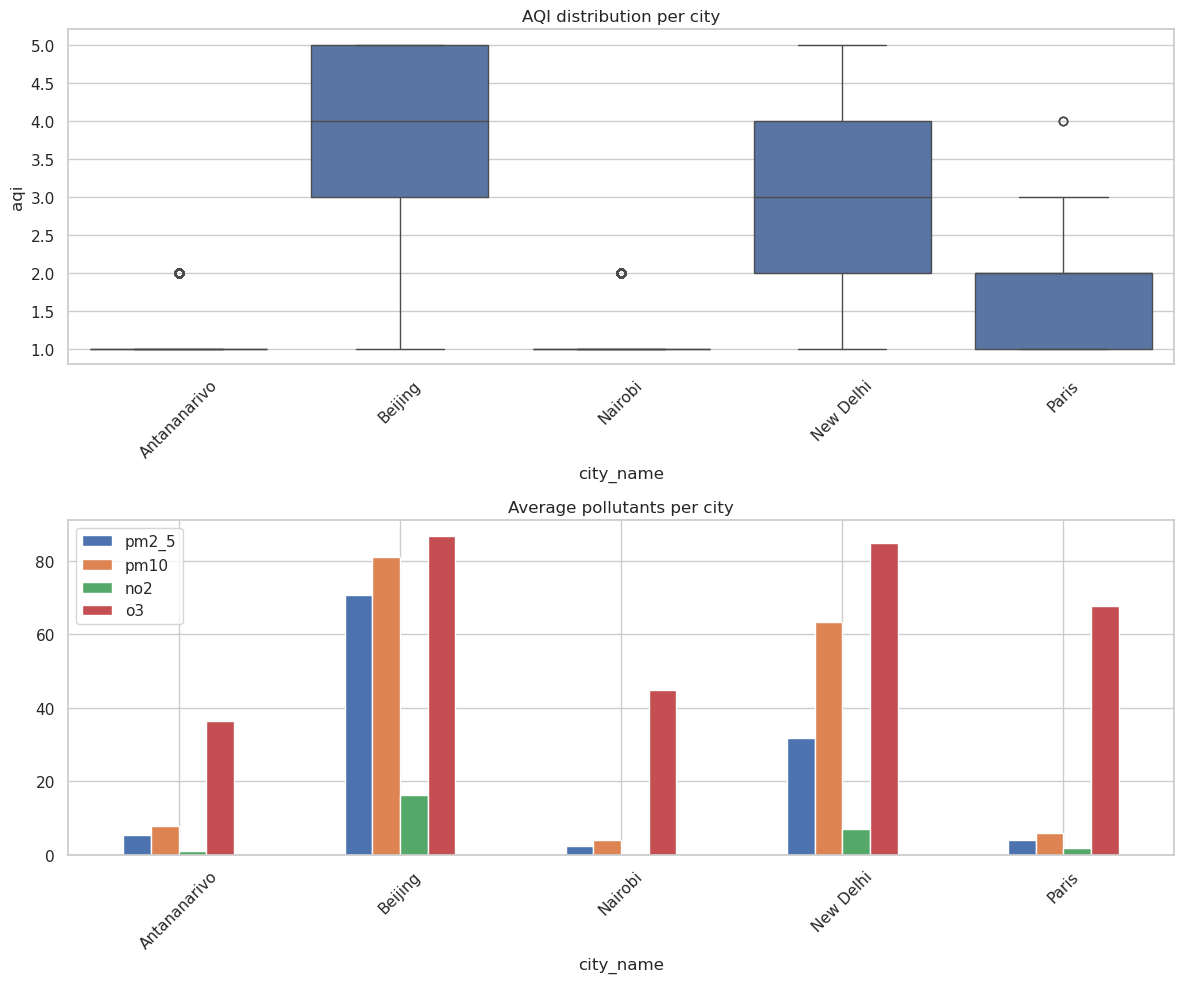

                  mean  median  max
city_name                          
Beijing       4.070736     4.0    5
New Delhi     3.009804     3.0    5
Paris         1.751916     2.0    4
Antananarivo  1.183429     1.0    2
Nairobi       1.099138     1.0    2


In [15]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# AQI distribution per city
sns.boxplot(data=df, x="city_name", y="aqi", ax=axes[0])
axes[0].set_title("AQI distribution per city")
axes[0].tick_params(axis="x", rotation=45)

# Average main pollutants per city
city_means = df.groupby("city_name")[["pm2_5", "pm10", "no2", "o3"]].mean()
city_means.plot(kind="bar", ax=axes[1])
axes[1].set_title("Average pollutants per city")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# City ranking by average AQI
ranking = df.groupby("city_name")["aqi"].agg(["mean", "median", "max"]).sort_values("mean", ascending=False)
print(ranking)

5. Time evolution

We look at how AQI moves over time, its average shape across the 24-hour cycle, and whether weekends differ from weekdays.

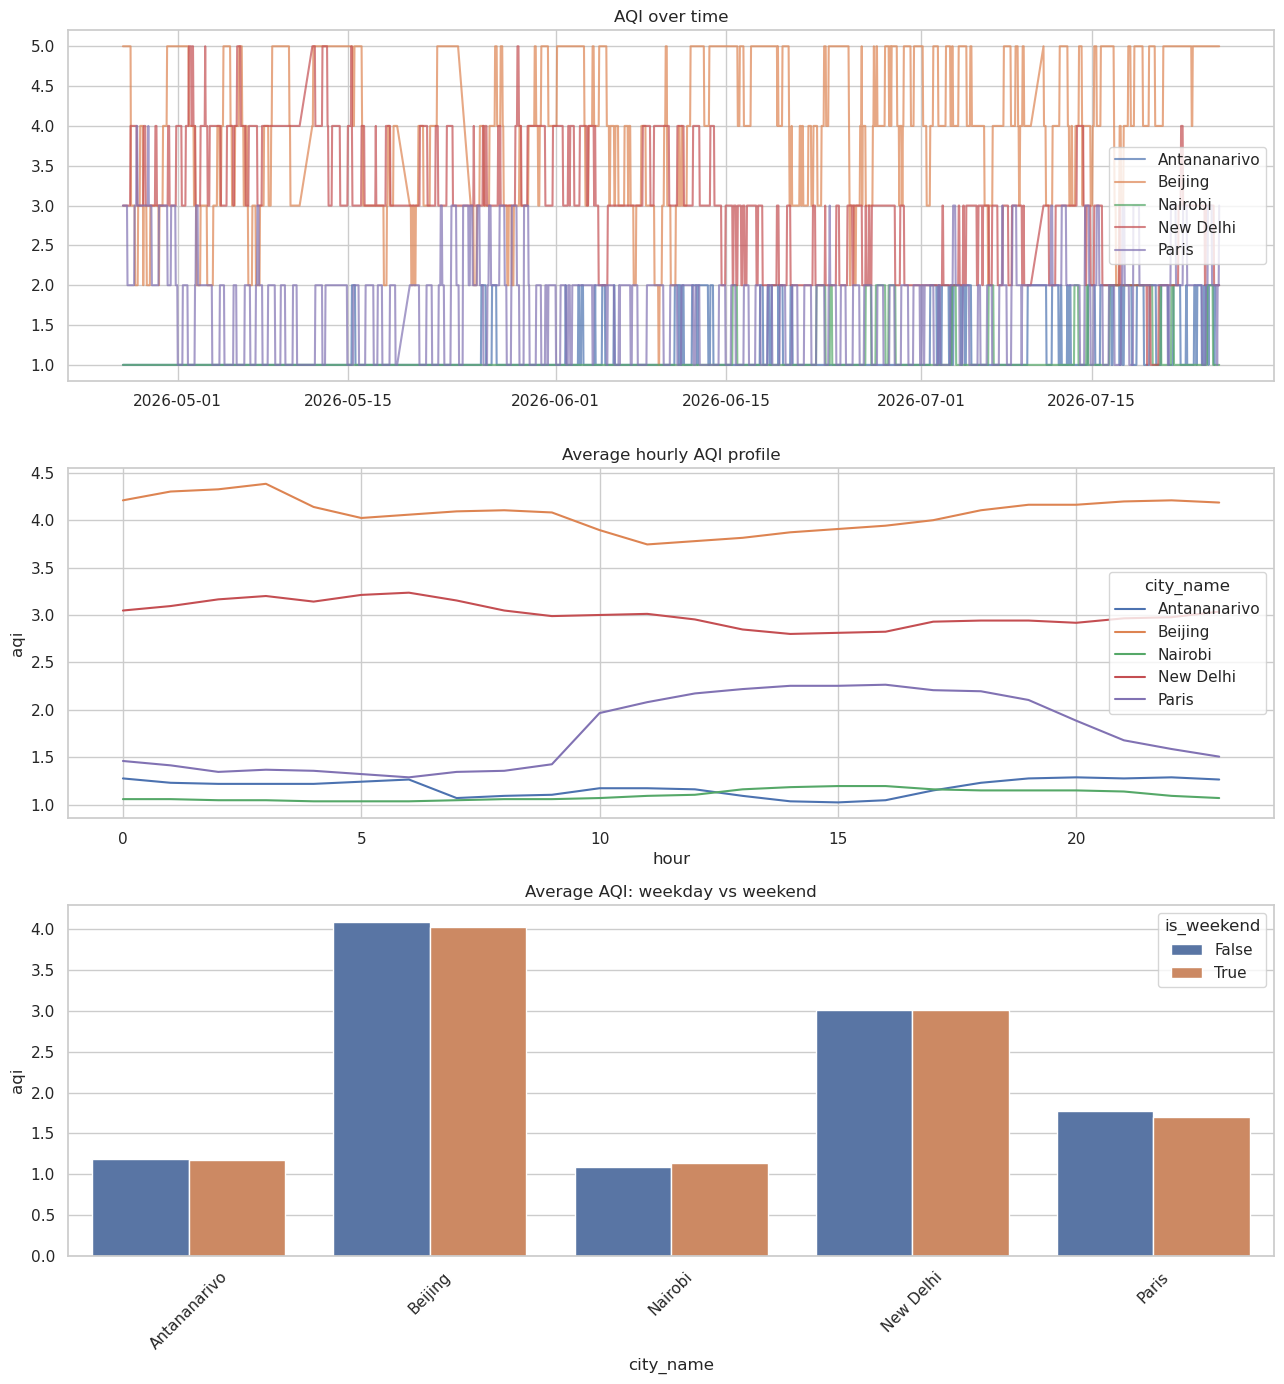

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(13, 14))

# AQI time series per city
for city in df["city_name"].unique():
    sub = df[df["city_name"] == city].sort_values("timestamp_utc")
    axes[0].plot(sub["timestamp_utc"], sub["aqi"], label=city, alpha=0.7)
axes[0].set_title("AQI over time")
axes[0].legend()

# Average hourly profile (day/night cycle — traffic, activity)
hourly = df.groupby(["city_name", "hour"])["aqi"].mean().reset_index()
sns.lineplot(data=hourly, x="hour", y="aqi", hue="city_name", ax=axes[1])
axes[1].set_title("Average hourly AQI profile")

# Weekday vs weekend
weekend_cmp = df.groupby(["city_name", "is_weekend"])["aqi"].mean().reset_index()
sns.barplot(data=weekend_cmp, x="city_name", y="aqi", hue="is_weekend", ax=axes[2])
axes[2].set_title("Average AQI: weekday vs weekend")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

6. Pollutant correlations

We measure how strongly each pollutant moves with AQI and with each other, to identify which ones are actually driving the index.

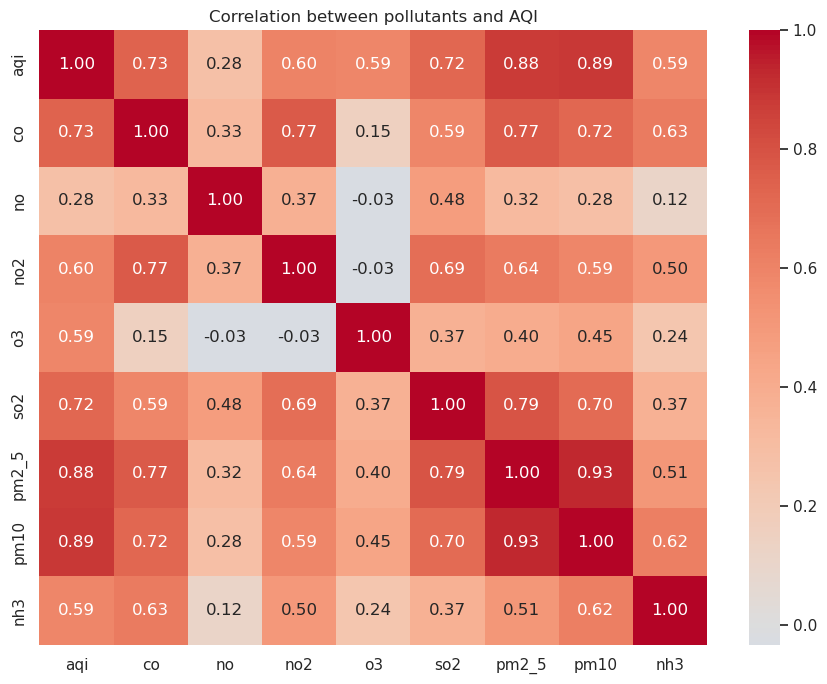

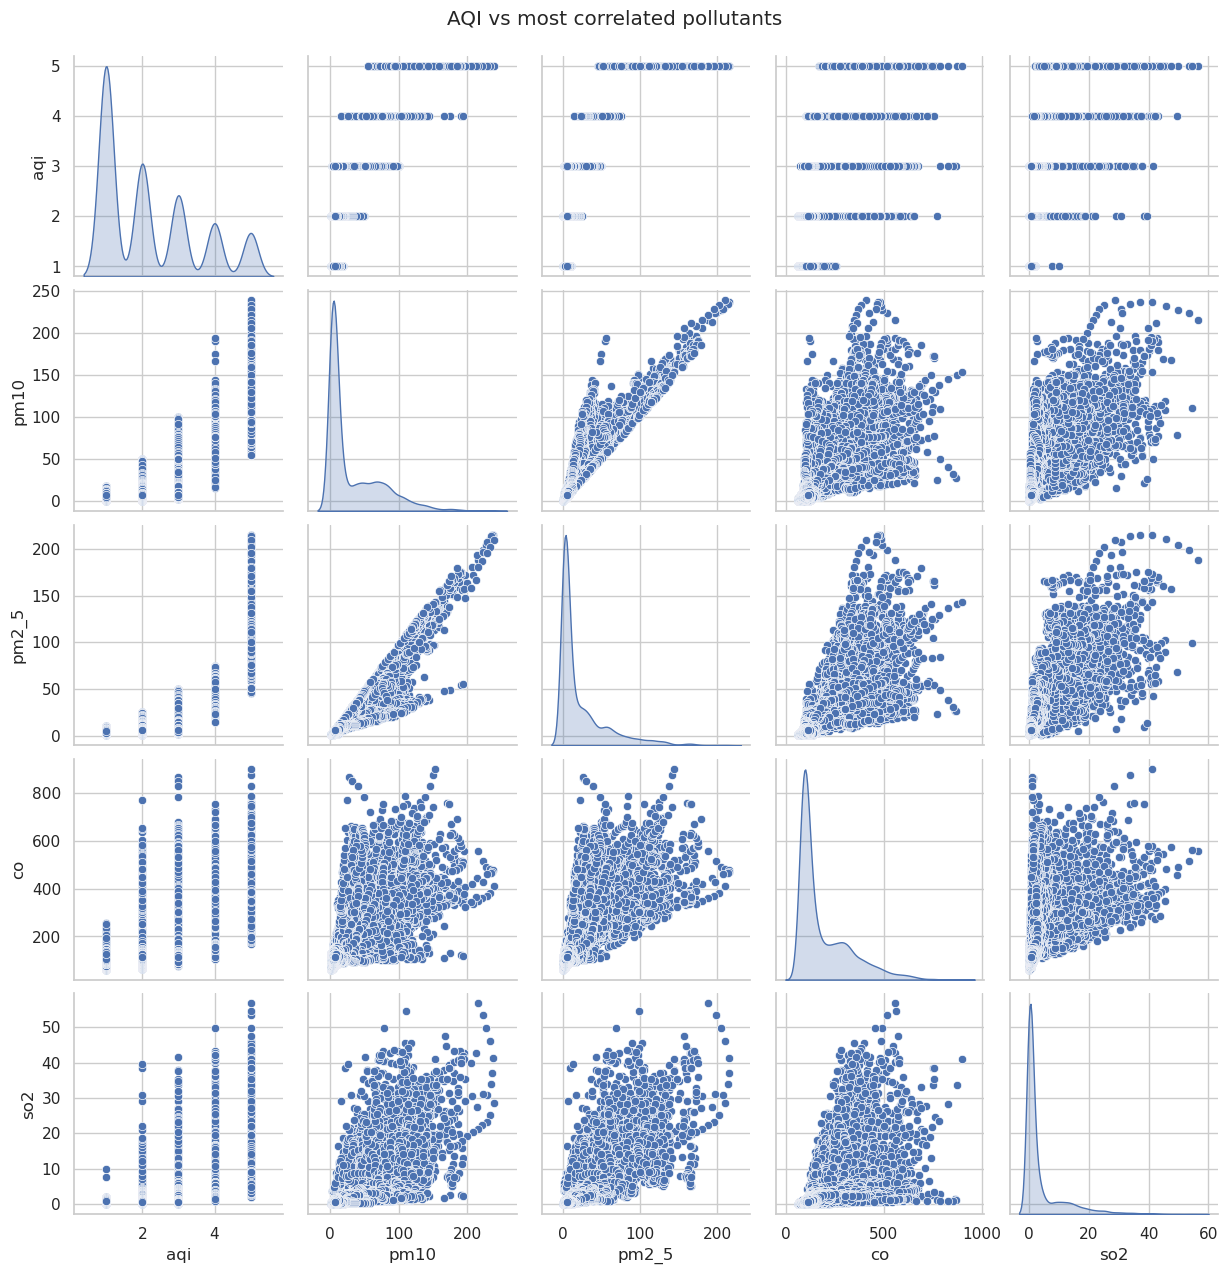

Pollutants most correlated with AQI :
pm10     0.887722
pm2_5    0.878782
co       0.733686
so2      0.718598
no2      0.603740
o3       0.590973
nh3      0.588916
no       0.277836
Name: aqi, dtype: float64


In [17]:
plt.figure(figsize=(9, 7))
corr = df[pollutant_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation between pollutants and AQI")
plt.tight_layout()
plt.show()

# Pairplot focused on the pollutants most correlated with AQI
top_corr = corr["aqi"].drop("aqi").abs().sort_values(ascending=False).head(4).index.tolist()
sns.pairplot(df[["aqi"] + top_corr].dropna(), diag_kind="kde")
plt.suptitle("AQI vs most correlated pollutants", y=1.02)
plt.show()

print("Pollutants most correlated with AQI :")
print(corr["aqi"].drop("aqi").abs().sort_values(ascending=False))

7. Geographic distribution

Using the latitude/longitude stored in dim_city, we place each city on a map and color it by average AQI to see spatial patterns at a glance.

In [18]:
import plotly.express as px

city_geo = df.groupby(["city_name", "latitude", "longitude"])["aqi"].mean().reset_index()
city_geo.columns = ["city_name", "latitude", "longitude", "avg_aqi"]

fig = px.scatter_geo(
    city_geo,
    lat="latitude",
    lon="longitude",
    color="avg_aqi",
    size="avg_aqi",
    hover_name="city_name",
    color_continuous_scale="RdYlGn_r",
    title="Average AQI by city location",
    projection="natural earth",
)
fig.update_geos(showcountries=True, showcoastlines=True)
fig.show()

print(city_geo.sort_values("avg_aqi", ascending=False))

      city_name  latitude  longitude   avg_aqi
1       Beijing   39.9042   116.4074  4.070736
3     New Delhi   28.6139    77.2090  3.009804
4         Paris   48.8566     2.3522  1.751916
0  Antananarivo  -18.8792    47.5079  1.183429
2       Nairobi   -1.2921    36.8219  1.099138


8. Seasonal / monthly trends

Hourly data is noisy, so we aggregate AQI by day and by month (from dim_time.date) to see the underlying trend instead of point-to-point fluctuation.

/tmp/ipykernel_12672/2701751402.py:1: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.

/tmp/ipykernel_12672/2701751402.py:2: UserWarning:

Converting to PeriodArray/Index representation will drop timezone information.



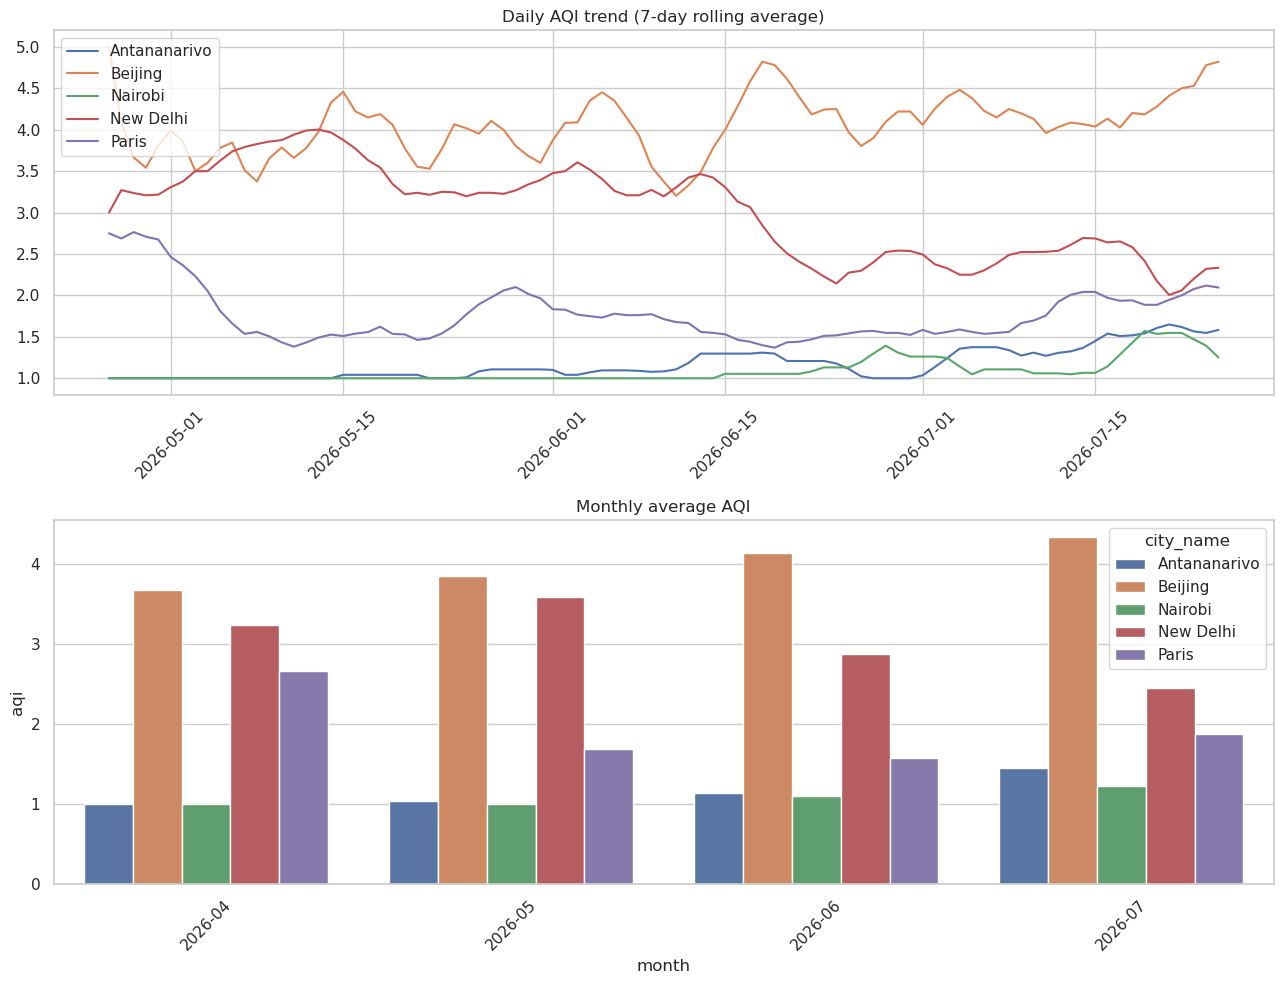

city_name  Antananarivo  Beijing  Nairobi  New Delhi  Paris
month                                                      
2026-04             1.0      3.7      1.0        3.2    2.7
2026-05             1.0      3.8      1.0        3.6    1.7
2026-06             1.1      4.1      1.1        2.9    1.6
2026-07             1.5      4.3      1.2        2.5    1.9


In [19]:
df["month"] = df["timestamp_utc"].dt.to_period("M").astype(str)
df["week"] = df["timestamp_utc"].dt.to_period("W").astype(str)

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Daily average AQI, smoothed with a 7-day rolling mean, per city
daily = df.groupby(["city_name", "date"])["aqi"].mean().reset_index()
for city in daily["city_name"].unique():
    sub = daily[daily["city_name"] == city].sort_values("date")
    sub["aqi_smooth"] = sub["aqi"].rolling(7, min_periods=1).mean()
    axes[0].plot(sub["date"], sub["aqi_smooth"], label=city)
axes[0].set_title("Daily AQI trend (7-day rolling average)")
axes[0].legend()
axes[0].tick_params(axis="x", rotation=45)

# Monthly average AQI per city
monthly = df.groupby(["city_name", "month"])["aqi"].mean().reset_index()
sns.barplot(data=monthly, x="month", y="aqi", hue="city_name", ax=axes[1])
axes[1].set_title("Monthly average AQI")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

print(monthly.pivot(index="month", columns="city_name", values="aqi").round(1))

9. Anomaly detection

We flag AQI readings that deviate strongly from a city's own recent behavior (z-score on a rolling window), which can point to sensor issues or real pollution spikes worth investigating.

/tmp/ipykernel_12672/3915255529.py:9: FutureWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



Anomalies detected : 95
      city_name             timestamp_utc  pm2_5  aqi   z_score
2104    Beijing 2026-04-27 04:00:00+00:00  25.23    3 -3.370418
6258  New Delhi 2026-04-27 06:00:00+00:00  57.87    4  3.095832
4175    Nairobi 2026-04-27 11:00:00+00:00   0.56    1  3.057437
4176    Nairobi 2026-04-27 12:00:00+00:00   0.59    1  3.468306
4177    Nairobi 2026-04-27 13:00:00+00:00   0.62    1  3.319466
...         ...                       ...    ...  ...       ...
8199  New Delhi 2026-07-22 03:00:00+00:00  26.53    3  3.119862
8202  New Delhi 2026-07-22 06:00:00+00:00  38.52    3  3.145913
8203  New Delhi 2026-07-22 07:00:00+00:00  48.36    3  3.244506
8204  New Delhi 2026-07-22 08:00:00+00:00  56.39    4  3.040302
4097    Beijing 2026-07-23 05:00:00+00:00  73.22    4 -3.058499

[95 rows x 5 columns]


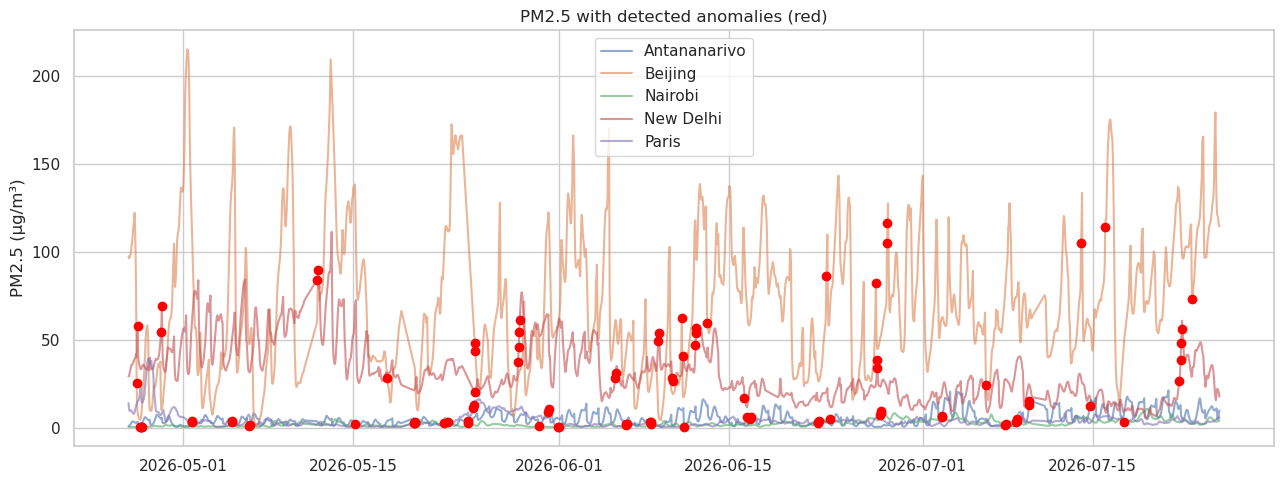


Anomalies per city :
city_name
New Delhi       26
Nairobi         23
Paris           19
Beijing         15
Antananarivo    12
Name: count, dtype: int64


In [21]:
def flag_anomalies(g, column="pm2_5", window=24, threshold=3):
    g = g.sort_values("timestamp_utc").copy()
    rolling_mean = g[column].rolling(window, min_periods=5).mean()
    rolling_std = g[column].rolling(window, min_periods=5).std()
    g["z_score"] = (g[column] - rolling_mean) / rolling_std
    g["is_anomaly"] = g["z_score"].abs() > threshold
    return g

df_anomalies = df.groupby("city_name", group_keys=False).apply(
    lambda g: flag_anomalies(g, column="pm2_5", window=24, threshold=3)
)

anomalies = df_anomalies[df_anomalies["is_anomaly"]].sort_values("timestamp_utc")
print(f"Anomalies detected : {len(anomalies)}")
print(anomalies[["city_name", "timestamp_utc", "pm2_5", "aqi", "z_score"]])

# Visualize anomalies over the pm2_5 time series
fig, ax = plt.subplots(figsize=(13, 5))
for city in df["city_name"].unique():
    sub = df_anomalies[df_anomalies["city_name"] == city].sort_values("timestamp_utc")
    ax.plot(sub["timestamp_utc"], sub["pm2_5"], label=city, alpha=0.6)
    anom = sub[sub["is_anomaly"]]
    if len(anom):
        ax.scatter(anom["timestamp_utc"], anom["pm2_5"], color="red", zorder=5)
ax.set_title("PM2.5 with detected anomalies (red)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

# Anomaly count per city, for a quick summary
print("\nAnomalies per city :")
print(anomalies["city_name"].value_counts())

10. Conclusion / summary

A single-page, plain-language dashboard: status lights, key numbers, and a written verdict — designed so anyone (not just a data analyst) understands the warehouse's health and findings at a glance.

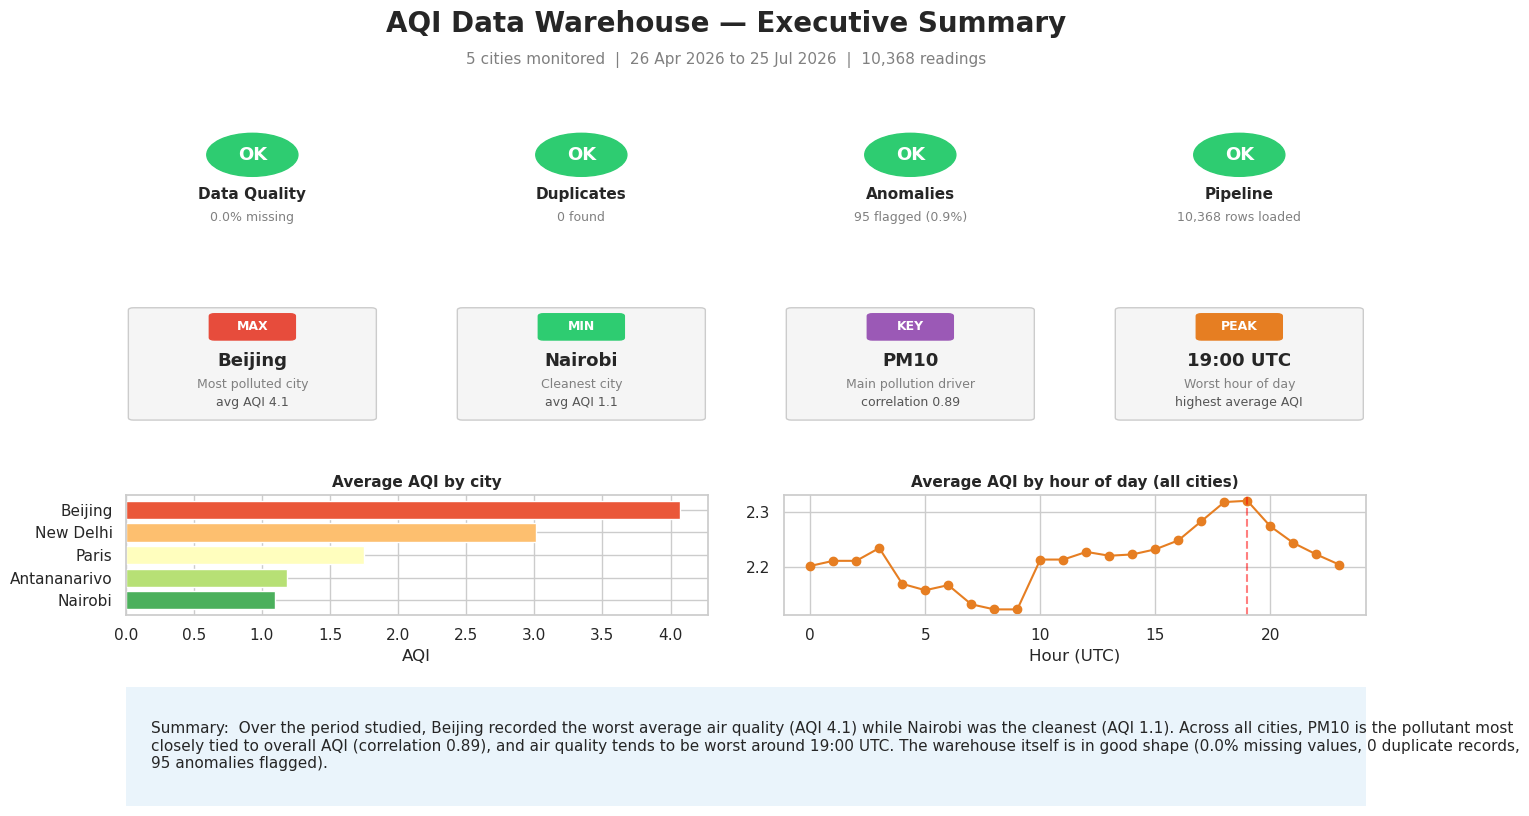

In [ ]:
from matplotlib.patches import FancyBboxPatch
import matplotlib.gridspec as gridspec

# --- Compute all summary figures ---
n_cities = df["city_name"].nunique()
n_rows = len(df)
n_missing = df[pollutant_cols].isna().sum().sum()
missing_pct = n_missing / (n_rows * len(pollutant_cols)) * 100
n_dupes = df.duplicated(subset=["city_name", "timestamp_utc"]).sum()
n_anomalies = len(anomalies)
anomaly_pct = n_anomalies / n_rows * 100

most_polluted = ranking["mean"].idxmax()
most_polluted_val = ranking["mean"].max()
least_polluted = ranking["mean"].idxmin()
least_polluted_val = ranking["mean"].min()

top_pollutant = corr["aqi"].drop("aqi").abs().sort_values(ascending=False).index[0]
top_pollutant_corr = corr["aqi"][top_pollutant]

peak_hour = hourly.groupby("hour")["aqi"].mean().idxmax()
period_start = df["timestamp_utc"].min().strftime("%d %b %Y")
period_end = df["timestamp_utc"].max().strftime("%d %b %Y")

# --- Traffic-light status helper ---
def status_color(pct, good=1, warn=5):
    if pct < good:
        return "#2ecc71", "GOOD"
    elif pct < warn:
        return "#f39c12", "WATCH"
    else:
        return "#e74c3c", "ISSUE"

quality_color, quality_label = status_color(missing_pct, good=1, warn=5)
anomaly_color, anomaly_label = status_color(anomaly_pct, good=1, warn=3)
dupe_color, dupe_label = status_color(n_dupes / n_rows * 100, good=0.1, warn=1)

# --- Figure layout ---
fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.6, wspace=0.3)

# Title (no emoji)
fig.text(0.5, 0.97, "AQI Data Warehouse — Executive Summary", ha="center", fontsize=20, fontweight="bold")
fig.text(0.5, 0.935, f"{n_cities} cities monitored  |  {period_start} to {period_end}  |  {n_rows:,} readings",
         ha="center", fontsize=11, color="gray")

# --- Row 1: Status lights (traffic light system, drawn as shapes not emoji) ---
status_items = [
    ("Data Quality", quality_label, quality_color, f"{missing_pct:.1f}% missing"),
    ("Duplicates", dupe_label, dupe_color, f"{n_dupes} found"),
    ("Anomalies", anomaly_label, anomaly_color, f"{n_anomalies} flagged ({anomaly_pct:.1f}%)"),
    ("Pipeline", "GOOD" if n_rows > 0 else "ISSUE", "#2ecc71" if n_rows > 0 else "#e74c3c", f"{n_rows:,} rows loaded"),
]
for i, (title, label, color, detail) in enumerate(status_items):
    ax = fig.add_subplot(gs[0, i])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    circle = plt.Circle((0.5, 0.65), 0.18, color=color)
    ax.add_patch(circle)
    symbol = "OK" if label == "GOOD" else ("!" if label == "WATCH" else "X")
    ax.text(0.5, 0.65, symbol, ha="center", va="center", fontsize=13, color="white", fontweight="bold")
    ax.text(0.5, 0.28, title, ha="center", fontsize=11, fontweight="bold")
    ax.text(0.5, 0.10, detail, ha="center", fontsize=9, color="gray")

# --- Row 2: Key findings cards (text labels instead of emoji icons) ---
findings = [
    ("MAX", "Most polluted city", most_polluted, f"avg AQI {most_polluted_val:.1f}", "#e74c3c"),
    ("MIN", "Cleanest city", least_polluted, f"avg AQI {least_polluted_val:.1f}", "#2ecc71"),
    ("KEY", "Main pollution driver", top_pollutant.upper(), f"correlation {top_pollutant_corr:.2f}", "#9b59b6"),
    ("PEAK", "Worst hour of day", f"{peak_hour}:00 UTC", "highest average AQI", "#e67e22"),
]
for i, (tag, title, value, detail, color) in enumerate(findings):
    ax = fig.add_subplot(gs[1, i])
    ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
    ax.add_patch(FancyBboxPatch((0.03, 0.05), 0.94, 0.9, boxstyle="round,pad=0.02",
                                 facecolor="#f5f5f5", edgecolor="#ccc", linewidth=1))
    ax.add_patch(FancyBboxPatch((0.35, 0.72), 0.3, 0.18, boxstyle="round,pad=0.02",
                                 facecolor=color, edgecolor=color))
    ax.text(0.5, 0.81, tag, ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax.text(0.5, 0.48, value, ha="center", fontsize=13, fontweight="bold")
    ax.text(0.5, 0.30, title, ha="center", fontsize=9, color="gray")
    ax.text(0.5, 0.15, detail, ha="center", fontsize=9, color="#555")

# --- Row 3: mini bar chart (city ranking) ---
ax_bar = fig.add_subplot(gs[2, 0:2])
ranking_sorted = ranking["mean"].sort_values()
colors_bar = sns.color_palette("RdYlGn_r", len(ranking_sorted))
ax_bar.barh(ranking_sorted.index, ranking_sorted.values, color=colors_bar)
ax_bar.set_title("Average AQI by city", fontsize=11, fontweight="bold")
ax_bar.set_xlabel("AQI")

# --- Row 3: mini hourly profile ---
ax_line = fig.add_subplot(gs[2, 2:4])
overall_hourly = df.groupby("hour")["aqi"].mean()
ax_line.plot(overall_hourly.index, overall_hourly.values, marker="o", color="#e67e22")
ax_line.axvline(peak_hour, color="red", linestyle="--", alpha=0.5)
ax_line.set_title("Average AQI by hour of day (all cities)", fontsize=11, fontweight="bold")
ax_line.set_xlabel("Hour (UTC)")

# --- Row 4: Written verdict in plain language ---
ax_text = fig.add_subplot(gs[3, :])
ax_text.axis("off")

verdict = (
    f"Summary:  Over the period studied, {most_polluted} recorded the worst average air quality "
    f"(AQI {most_polluted_val:.1f}) while {least_polluted} was the cleanest (AQI {least_polluted_val:.1f}). "
    f"Across all cities, {top_pollutant.upper()} is the pollutant most closely tied to overall AQI (correlation {top_pollutant_corr:.2f}), "
    f"and air quality tends to be worst around {peak_hour}:00 UTC. "
    f"The warehouse itself is in {'good shape' if quality_label == 'GOOD' and dupe_label == 'GOOD' else 'a state that needs review'} "
    f"({missing_pct:.1f}% missing values, {n_dupes} duplicate records, {n_anomalies} anomalies flagged)."
)
ax_text.add_patch(FancyBboxPatch((0.0, 0.0), 1.0, 1.0, boxstyle="round,pad=0.02",
                                  facecolor="#eaf4fb", edgecolor="#3498db", linewidth=1.5, transform=ax_text.transAxes))
ax_text.text(0.02, 0.5, verdict, ha="left", va="center", fontsize=11, wrap=True,
             transform=ax_text.transAxes, family="sans-serif")

plt.show()